In [2]:
pip install ucimlrepo

In [3]:
# 1. IMPORT LIBRARIES (The absolute first step)
import pandas as pd
import numpy as np

In [4]:
from ucimlrepo import fetch_ucirepo

#2. fetch dataset
online_retail = fetch_ucirepo(id=352)

# data (as pandas dataframes)
X = online_retail.data.features
y = online_retail.data.targets

# metadata
print(online_retail.metadata)

# variable information
print(online_retail.variables)


{'uci_id': 352, 'name': 'Online Retail', 'repository_url': 'https://archive.ics.uci.edu/dataset/352/online+retail', 'data_url': 'https://archive.ics.uci.edu/static/public/352/data.csv', 'abstract': 'This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate', 'Sequential', 'Time-Series'], 'num_instances': 541909, 'num_features': 6, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': None, 'index_col': ['InvoiceNo', 'StockCode'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Oct 21 2024', 'dataset_doi': '10.24432/C5BW33', 'creators': ['Daqing Chen'], 'intro_paper': {'ID': 361, 'type': 'NATIVE', 'title': 'Data mining for the online retail industry: A case study of RFM model-based customer segmenta

In [5]:
# Rename X to df for easier use
df = X.copy()

# Check the shape and column types
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Description  540455 non-null  object 
 1   Quantity     541909 non-null  int64  
 2   InvoiceDate  541909 non-null  object 
 3   UnitPrice    541909 non-null  float64
 4   CustomerID   406829 non-null  float64
 5   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 24.8+ MB
None


In [6]:
# 3. AUDIT & REMOVE NULLS
# Identify rows with missing CustomerID
missing_ids = df['CustomerID'].isnull().sum()
print(f"Rows missing CustomerID:",missing_ids)

Rows missing CustomerID: 135080


In [7]:
# Remove rows where CustomerID is missing
df_clean = df.dropna(subset=['CustomerID'])
print(f"cleaned dataset",df_clean )

cleaned dataset                                 Description  Quantity      InvoiceDate  \
0        WHITE HANGING HEART T-LIGHT HOLDER         6   12/1/2010 8:26   
1                       WHITE METAL LANTERN         6   12/1/2010 8:26   
2            CREAM CUPID HEARTS COAT HANGER         8   12/1/2010 8:26   
3       KNITTED UNION FLAG HOT WATER BOTTLE         6   12/1/2010 8:26   
4            RED WOOLLY HOTTIE WHITE HEART.         6   12/1/2010 8:26   
...                                     ...       ...              ...   
541904          PACK OF 20 SPACEBOY NAPKINS        12  12/9/2011 12:50   
541905         CHILDREN'S APRON DOLLY GIRL          6  12/9/2011 12:50   
541906        CHILDRENS CUTLERY DOLLY GIRL          4  12/9/2011 12:50   
541907      CHILDRENS CUTLERY CIRCUS PARADE         4  12/9/2011 12:50   
541908        BAKING SET 9 PIECE RETROSPOT          3  12/9/2011 12:50   

        UnitPrice  CustomerID         Country  
0            2.55     17850.0  United Kingdom  

In [8]:
# Verify the result
print(f"Rows before: {len(df)}")
print(f"Rows after: {len(df_clean)}")
print(f"Percentage of data retained: {round(len(df_clean)/len(df)*100, 2)}%")

Rows before: 541909
Rows after: 406829
Percentage of data retained: 75.07%


Identified that 25% of transactional data lacked customer attribution, performed a data integrity audit, and established a cleaned baseline for retention modeling.

In [9]:
# 4. STRUCTURAL CLEANING
# . Summary of all missing values
print("--- Missing Values Audit ---")
print(df.isnull().sum())

# . Check for 'UnitPrice' issues
# High-end audit: Are there products with a 0.00 price? (Usually samples or gifts)
zero_price = df[df['UnitPrice'] == 0]
print(f"\nTransactions with 0.00 UnitPrice: {len(zero_price)}")

# . Check for 'Description' issues
# Sometimes the Description is missing but the StockCode exists.
missing_desc = df[df['Description'].isnull()]
print(f"Transactions with missing Descriptions: {len(missing_desc)}")

# . Quantity Audit
# Identify how many rows represent 'Returns' (Negative Quantity)
neg_quantity = df[df['Quantity'] < 0]
print(f"Negative Quantity rows (Returns/Adjustments): {len(neg_quantity)}")

--- Missing Values Audit ---
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Transactions with 0.00 UnitPrice: 2515
Transactions with missing Descriptions: 1454
Negative Quantity rows (Returns/Adjustments): 10624


In [10]:
print("Actual Columns in DataFrame:", df.columns.tolist())

Actual Columns in DataFrame: ['Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [11]:
# This strips any hidden spaces from the headers so 'InvoiceNo' can be found
df_clean.columns = df_clean.columns.str.strip()

In [12]:
# 1. Reset the index to bring back InvoiceNo and StockCode
# This is likely where they are 'hiding'
df_clean = df_clean.reset_index()

# 2. Check the columns again to be 100% sure
print("New Columns after reset:", df_clean.columns.tolist())


New Columns after reset: ['index', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [13]:
 #3. Clean names (just in case there are spaces)
df_clean.columns = df_clean.columns.str.strip()

# 4. NOW try the Structural Cleaning again
# Convert Date
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Create Revenue
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

In [14]:
# Fetch the original InvoiceNo and StockCode columns using the 'index' mapping
original_ids_data = online_retail.data.original[['InvoiceNo', 'StockCode']]

# Ensure original_ids_data has a default integer index for merging
original_ids_data = original_ids_data.reset_index(drop=True)

# Merge InvoiceNo and StockCode into df_clean using the 'index' column (which holds original row indices)
df_clean = df_clean.merge(original_ids_data, left_on='index', right_index=True, how='left')

# Identify Returns using InvoiceNo (it should be there now!)
df_clean['Is_Return'] = df_clean['InvoiceNo'].astype(str).str.contains('C', na=False)

# 5. Separate Sales and Returns
df_sales = df_clean[df_clean['Is_Return'] == False].copy()
df_returns = df_clean[df_clean['Is_Return'] == True].copy()

print(f"\n✅ Success! Identified {len(df_sales)} Sales and {len(df_returns)} Returns.")


✅ Success! Identified 397924 Sales and 8905 Returns.


In [15]:
# 1. Identify Returns
# We use the 'InvoiceNo' which we just recovered with reset_index()
# Returns are marked with a 'C' (for Cancellation)
df_clean['Is_Return'] = df_clean['InvoiceNo'].astype(str).str.contains('C', na=False)

# 2. Create a Transaction Type Column
# This is a 'Consultant' move: instead of deleting data, we label it for analysis
df_clean['Transaction_Type'] = np.where(df_clean['Is_Return'], 'Return', 'Sale')

# 3. Separate into two DataFrames
# This makes Month 3 (Power BI) much easier to handle
df_sales = df_clean[df_clean['Transaction_Type'] == 'Sale'].copy()
df_returns = df_clean[df_clean['Transaction_Type'] == 'Return'].copy()

# 4. Final Audit Printout
print("--- Final  Audit ---")
print(f"Total Successful Sales: {len(df_sales)}")
print(f"Total Returns Identified: {len(df_returns)}")
print(f"Gross Revenue: £{df_sales['Revenue'].sum():,.2f}")
print(f"Refunded Amount: £{abs(df_returns['Revenue'].sum()):,.2f}")

# 5. Export for SQL
df_sales.to_csv('sales_data.csv', index=False)
df_returns.to_csv('returns_data.csv', index=False)

--- Final  Audit ---
Total Successful Sales: 397924
Total Returns Identified: 8905
Gross Revenue: £8,911,407.90
Refunded Amount: £611,342.09


In [16]:
# 1. Create the Sales Fact Table (All successful transactions)
# We only want 'Sales' (not returns) for our primary spend analysis
df_sales = df_clean[df_clean['Quantity'] > 0].copy()

# 2. Create a Customer Dimension Table
# This is a list of unique customers and where they are from
df_customers = df_clean[['CustomerID', 'Country']].drop_duplicates()

# 3. Create a Product Dimension Table
# This maps StockCodes to Descriptions
df_products = df_clean[['StockCode', 'Description']].drop_duplicates(subset=['StockCode'])

print(f"Tables Prepared: {len(df_sales)} Sales, {len(df_customers)} Customers, {len(df_products)} Products")

Tables Prepared: 397924 Sales, 4380 Customers, 3684 Products


In [17]:
import sqlite3

# 1. Connect to your database
conn = sqlite3.connect('retail_audit.db')

# 2. Create Dimension: Customers (Unique list of people)
# We drop duplicates so each CustomerID appears only ONCE
df_customers = df_clean[['CustomerID', 'Country']].drop_duplicates(subset=['CustomerID'])

# 3. Create Dimension: Products (Unique list of items)
df_products = df_clean[['StockCode', 'Description']].drop_duplicates(subset=['StockCode'])

# 4. Create Fact Table: Sales (The actual transactions)
# We focus on the 'Numbers' here
df_sales_fact = df_clean[['InvoiceNo', 'StockCode', 'CustomerID', 'InvoiceDate', 'Quantity', 'UnitPrice', 'Revenue']]

# 5. Load everything into SQL
df_customers.to_sql('dim_customers', conn, if_exists='replace', index=False)
df_products.to_sql('dim_products', conn, if_exists='replace', index=False)
df_sales_fact.to_sql('fact_sales', conn, if_exists='replace', index=False)

print("✅ Star Schema created! Your database is now structured like a professional data warehouse.")

✅ Star Schema created! Your database is now structured like a professional data warehouse.


Total Revenue per Country

In [18]:
sql_query = """
SELECT
    c.Country,
    SUM(s.Revenue) AS Total_Revenue
FROM fact_sales s
JOIN dim_customers c ON s.CustomerID = c.CustomerID
GROUP BY c.Country
ORDER BY Total_Revenue DESC;
"""

# Execute the SQL query using pandas read_sql_query
revenue_by_country = pd.read_sql_query(sql_query, conn)

# Display the result
print(revenue_by_country)

                 Country  Total_Revenue
0         United Kingdom   6.767873e+06
1            Netherlands   2.846615e+05
2                   EIRE   2.502852e+05
3                Germany   2.216982e+05
4                 France   1.967128e+05
5              Australia   1.384674e+05
6            Switzerland   5.551839e+04
7                  Spain   5.357032e+04
8                Belgium   4.126588e+04
9                 Sweden   3.659591e+04
10                 Japan   3.534062e+04
11                Norway   3.516346e+04
12              Portugal   2.905981e+04
13               Finland   2.232674e+04
14       Channel Islands   2.008629e+04
15               Denmark   1.831472e+04
16                 Italy   1.689051e+04
17                Cyprus   1.379510e+04
18               Austria   9.439140e+03
19             Singapore   9.120390e+03
20                Poland   7.213140e+03
21                Israel   6.994250e+03
22                Greece   4.710520e+03
23               Iceland   4.310000e+03


**Which Countries generate the most Profit?**

In [19]:
query = """
SELECT c.Country, SUM(s.Revenue) as Total_Revenue
FROM fact_sales s
JOIN dim_customers c ON s.CustomerID = c.CustomerID
GROUP BY c.Country
ORDER BY Total_Revenue DESC
LIMIT 5;
"""
pd.read_sql(query, conn)

,Country,Total_Revenue
0,United Kingdom,6.767873e+06
1,Netherlands,2.846615e+05
2,EIRE,2.502852e+05
3,Germany,2.216982e+05
4,France,1.967128e+05


**Top 5 Best-Selling Product Descriptions**

In [20]:
query = """
SELECT p.Description, SUM(s.Quantity) as Total_Sold
FROM fact_sales s
JOIN dim_products p ON s.StockCode = p.StockCode
GROUP BY p.Description
ORDER BY Total_Sold DESC
LIMIT 5;
"""
pd.read_sql(query, conn)

,Description,Total_Sold
0,WORLD WAR 2 GLIDERS ASSTD DESIGNS,53215
1,SMALL POPCORN HOLDER,48712
2,JUMBO BAG RED RETROSPOT,45066
3,ASSORTED COLOUR BIRD ORNAMENT,35314
4,WHITE HANGING HEART T-LIGHT HOLDER,34204


In [21]:
query_1 = """
SELECT
    c.Country,
    ROUND(SUM(s.Revenue), 2) AS Total_Revenue,
    COUNT(DISTINCT s.InvoiceNo) AS Transaction_Count
FROM fact_sales s
JOIN dim_customers c ON s.CustomerID = c.CustomerID
GROUP BY c.Country
ORDER BY Total_Revenue DESC
LIMIT 5;
"""
print("--- Challenge 1: Top 5 Countries by Revenue ---")
print(pd.read_sql(query_1, conn))

--- Challenge 1: Top 5 Countries by Revenue ---
          Country  Total_Revenue  Transaction_Count
0  United Kingdom     6767873.39              19857
1     Netherlands      284661.54                101
2            EIRE      250285.22                319
3         Germany      221698.21                603
4          France      196712.84                458


In [22]:
query_2 = """
SELECT
    p.Description,
    SUM(s.Quantity) AS Units_Sold
FROM fact_sales s
JOIN dim_products p ON s.StockCode = p.StockCode
WHERE p.Description IS NOT NULL
GROUP BY p.Description
ORDER BY Units_Sold DESC
LIMIT 5;
"""
print("\n--- Challenge 2: Top 5 Best-Selling Products ---")
print(pd.read_sql(query_2, conn))


--- Challenge 2: Top 5 Best-Selling Products ---
                          Description  Units_Sold
0   WORLD WAR 2 GLIDERS ASSTD DESIGNS       53215
1                SMALL POPCORN HOLDER       48712
2             JUMBO BAG RED RETROSPOT       45066
3       ASSORTED COLOUR BIRD ORNAMENT       35314
4  WHITE HANGING HEART T-LIGHT HOLDER       34204


In [23]:
query_3 = """
SELECT
    CustomerID,
    COUNT(DISTINCT InvoiceNo) AS Order_Frequency,
    ROUND(SUM(Revenue), 2) AS Lifetime_Value
FROM fact_sales
GROUP BY CustomerID
ORDER BY Lifetime_Value DESC
LIMIT 5;
"""
print("\n--- Challenge 3: Top 5 High-Value Customers ---")
print(pd.read_sql(query_3, conn))


--- Challenge 3: Top 5 High-Value Customers ---
   CustomerID  Order_Frequency  Lifetime_Value
0     14646.0               77       279489.02
1     18102.0               62       256438.49
2     17450.0               55       187482.17
3     14911.0              248       132572.62
4     12415.0               26       123725.45


The Recency Audit

In [24]:
import pandas as pd
import sqlite3

# 1. Setup the Snapshot Date
# Since the dataset ends in Dec 2011, we use 2011-12-10 as our 'Today'
snapshot_date = '2011-12-10'

# 2. SQL Query to Calculate Recency
# JULIANDAY converts a date string into a numerical value we can subtract
query_recency = f"""
SELECT
    CustomerID,
    MAX(InvoiceDate) AS Last_Purchase_Date,
    CAST(JULIANDAY('{snapshot_date}') - JULIANDAY(MAX(InvoiceDate)) AS INT) AS Recency
FROM fact_sales
GROUP BY CustomerID
ORDER BY Recency ASC;
"""

# 3. Execute and Store
df_recency = pd.read_sql(query_recency, conn)

# 4. Audit Summary
print("--- Week 1: Recency Distribution ---")
print(df_recency['Recency'].describe())

# 5. Show Top 5 'Active' vs Top 5 'Dormant'
print("\nMost Recent Customers (Active):")
print(df_recency.head(5))

print("\nLeast Recent Customers (At Risk):")
print(df_recency.tail(5))

--- Week 1: Recency Distribution ---
count    4372.000000
mean       91.581199
std       100.772139
min         0.000000
25%        16.000000
50%        50.000000
75%       143.000000
max       373.000000
Name: Recency, dtype: float64

Most Recent Customers (Active):
   CustomerID   Last_Purchase_Date  Recency
0     12423.0  2011-12-09 10:10:00        0
1     12433.0  2011-12-09 10:02:00        0
2     12518.0  2011-12-09 10:13:00        0
3     12526.0  2011-12-09 12:09:00        0
4     12662.0  2011-12-09 11:59:00        0

Least Recent Customers (At Risk):
      CustomerID   Last_Purchase_Date  Recency
4367     17643.0  2010-12-01 14:38:00      373
4368     17908.0  2010-12-01 11:45:00      373
4369     17968.0  2010-12-01 12:23:00      373
4370     18011.0  2010-12-01 17:35:00      373
4371     18074.0  2010-12-01 09:53:00      373


Calculating Frequency

In [25]:
# SQL query to get Frequency (Count of unique invoices)
query_frequency = """
SELECT
    CustomerID,
    COUNT(DISTINCT InvoiceNo) AS Frequency
FROM fact_sales
GROUP BY CustomerID;
"""

df_frequency = pd.read_sql(query_frequency, conn)

# Merge Frequency into our existing Recency table
df_rf = pd.merge(df_recency, df_frequency, on='CustomerID')

print("--- Week 2: Frequency Audit ---")
print(df_rf[['CustomerID', 'Recency', 'Frequency']].head(10))

--- Week 2: Frequency Audit ---
   CustomerID  Recency  Frequency
0     12423.0        0          9
1     12433.0        0          7
2     12518.0        0          5
3     12526.0        0          3
4     12662.0        0         12
5     12680.0        0          4
6     12713.0        0          1
7     12748.0        0        224
8     12985.0        0          3
9     13069.0        0         27


Recency (the "When") and Frequency (the "How Often"), the logical next step to complete the "Big Three" of customer analytics is Monetary Value(how much).

In [26]:
# SQL query to get Monetary Value (Total Spend)
query_monetary = """
SELECT
    CustomerID,
    SUM(Revenue) AS Monetary
FROM fact_sales
GROUP BY CustomerID;
"""

df_monetary = pd.read_sql(query_monetary, conn)

# 2. Merge all three together into one Master RFM Table
# We merge df_monetary into our previous df_rf table
df_rfm = pd.merge(df_rf, df_monetary, on='CustomerID')

# 3. View the Result
print("--- Week 3: The Complete RFM Table ---")
print(df_rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary']].head(10))

# 4. Statistical Audit of Spend
print("\n--- Monetary Spend Distribution ---")
print(df_rfm['Monetary'].describe())

--- Week 3: The Complete RFM Table ---
   CustomerID  Recency  Frequency  Monetary
0     12423.0        0          9   1849.11
1     12433.0        0          7  13375.87
2     12518.0        0          5   2056.89
3     12526.0        0          3   1316.66
4     12662.0        0         12   3817.08
5     12680.0        0          4    862.81
6     12713.0        0          1    848.55
7     12748.0        0        224  29072.10
8     12985.0        0          3   1215.62
9     13069.0        0         27   3717.82

--- Monetary Spend Distribution ---
count      4372.000000
mean       1898.459701
std        8219.345141
min       -4287.630000
25%         293.362500
50%         648.075000
75%        1611.725000
max      279489.020000
Name: Monetary, dtype: float64


Creating the "RFM Scorecard"
This is the final step. We use a method called Quantiles to rank customers against each other.

In [27]:
# Create 1-5 scores for Recency (Lower is better, so labels are reversed)
df_rfm['R_Score'] = pd.qcut(df_rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

# Create 1-5 scores for Frequency and Monetary (Higher is better)
# We use 'rank(method="first")' to handle duplicate values in Frequency
df_rfm['F_Score'] = pd.qcut(df_rfm['Frequency'].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
df_rfm['M_Score'] = pd.qcut(df_rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# Combine into a single RFM Score (e.g., 555 or 111)
df_rfm['RFM_Score'] = df_rfm['R_Score'].astype(str) + df_rfm['F_Score'].astype(str) + df_rfm['M_Score'].astype(str)

print("--- Week 4: RFM Scoring Complete ---")
print(df_rfm[['CustomerID', 'RFM_Score', 'Recency', 'Frequency', 'Monetary']].head())

--- Week 4: RFM Scoring Complete ---
   CustomerID RFM_Score  Recency  Frequency  Monetary
0     12423.0       554        0          9   1849.11
1     12433.0       545        0          7  13375.87
2     12518.0       545        0          5   2056.89
3     12526.0       534        0          3   1316.66
4     12662.0       555        0         12   3817.08


Human Labeling

In [28]:
# Define the segmentation map
segs = {
    r'[1-2][1-2]': 'Hibernating/Lost',
    r'[1-2][3-4]': 'At Risk',
    r'[1-2]5': 'Can\'t Lose Them',
    r'3[1-2]': 'About to Sleep',
    r'33': 'Need Attention',
    r'[3-4][4-5]': 'Loyal Customers',
    r'41': 'Promising',
    r'51': 'New Customers',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]': 'Champions'
}

# We use R and F scores for the main labels (Standard industry practice)
df_rfm['Segment'] = df_rfm['R_Score'].astype(str) + df_rfm['F_Score'].astype(str)
df_rfm['Segment'] = df_rfm['Segment'].replace(segs, regex=True)

print("--- Final Month 2 Result: Customer Segments ---")
print(df_rfm[['CustomerID', 'RFM_Score', 'Segment']].head(10))

# See the count of each segment
print("\nSegment Counts:")
print(df_rfm['Segment'].value_counts())

--- Final Month 2 Result: Customer Segments ---
   CustomerID RFM_Score              Segment
0     12423.0       554            Champions
1     12433.0       545            Champions
2     12518.0       545            Champions
3     12526.0       534  Potential Loyalists
4     12662.0       555            Champions
5     12680.0       533  Potential Loyalists
6     12713.0       513        New Customers
7     12748.0       555            Champions
8     12985.0       534  Potential Loyalists
9     13069.0       555            Champions

Segment Counts:
Segment
Hibernating/Lost       858
At Risk                797
Loyal Customers        796
Champions              663
About to Sleep         439
Potential Loyalists    420
Promising              151
Need Attention         119
Can't Lose Them         69
New Customers           60
Name: count, dtype: int64


In [29]:
# Group by Segment and calculate the averages
segment_analysis = df_rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

# Rename columns for clarity
segment_analysis.columns = ['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Customer_Count']

# Sort by Customer Count to see the biggest groups
segment_analysis = segment_analysis.sort_values(by='Customer_Count', ascending=False)

print("--- Executive Audit: Segment Performance ---")
print(segment_analysis)

--- Executive Audit: Segment Performance ---
                     Avg_Recency  Avg_Frequency  Avg_Monetary  Customer_Count
Segment                                                                      
Hibernating/Lost           221.7            1.0         327.0             858
At Risk                    167.5            3.0         850.4             797
Loyal Customers             32.3            8.0        2703.9             796
Champions                    5.1           14.6        6527.2             663
About to Sleep              51.4            1.4         455.5             439
Potential Loyalists         14.9            2.4         751.3             420
Promising                   22.6            1.0         299.5             151
Need Attention              49.0            3.0         899.8             119
Can't Lose Them            132.3            9.8        2506.3              69
New Customers                6.4            1.0         352.4              60


In [30]:
import plotly.express as px

# Prepare the data for the Treemap
top_segments = df_rfm['Segment'].value_counts().reset_index()
top_segments.columns = ['Segment', 'Count']

# Create the Treemap
fig = px.treemap(top_segments,
                 path=['Segment'],
                 values='Count',
                 title='Customer Segment Landscape',
                 color='Count',
                 color_continuous_scale='RdBu')

fig.show()

. Prepare the Map Data

In [31]:
# Aggregate Revenue by Country using SQL
query_map = """
SELECT c.Country, SUM(s.Revenue) as Total_Revenue
FROM fact_sales s
JOIN dim_customers c ON s.CustomerID = c.CustomerID
GROUP BY c.Country
ORDER BY Total_Revenue DESC;
"""
df_map = pd.read_sql(query_map, conn)

# Create the Interactive Choropleth Map
fig = px.choropleth(df_map,
                    locations="Country",
                    locationmode='country names',
                    color="Total_Revenue",
                    hover_name="Country",
                    title="Global Revenue Footprint",
                    color_continuous_scale=px.colors.sequential.Plasma)

fig.show()

The Revenue Share (The "80/20" Rule)
 we saw that Champions spend way more than anyone else. Let’s prove it with a Donut Chart showing the % of Total Revenue contributed by each segment.

In [32]:
# Calculate Total Revenue per Segment
segment_revenue = df_rfm.groupby('Segment')['Monetary'].sum().reset_index()

# Create the Donut Chart
fig = px.pie(segment_revenue,
             values='Monetary',
             names='Segment',
             hole=0.4,
             title='Total Revenue Contribution by Segment',
             color_discrete_sequence=px.colors.qualitative.Pastel)

fig.update_traces(textinfo='percent+label')
fig.show()

In [33]:
# Load the segmented data into the SQL database
df_rfm[['CustomerID', 'Segment']].to_sql('customer_segments', conn, if_exists='replace', index=False)

print("✅ Segment data uploaded to SQL for Deep-Dive.")

✅ Segment data uploaded to SQL for Deep-Dive.


In [34]:
query_champions_products = """
SELECT
    p.Description,
    SUM(s.Quantity) AS Total_Quantity
FROM fact_sales s
JOIN dim_products p ON s.StockCode = p.StockCode
JOIN customer_segments cs ON s.CustomerID = cs.CustomerID
WHERE cs.Segment = 'Champions'
GROUP BY p.Description
ORDER BY Total_Quantity DESC
LIMIT 5;
"""

df_champ_products = pd.read_sql(query_champions_products, conn)
print("--- Week 2: What Champions are Buying ---")
print(df_champ_products)

--- Week 2: What Champions are Buying ---
                          Description  Total_Quantity
0   WORLD WAR 2 GLIDERS ASSTD DESIGNS           31559
1                SMALL POPCORN HOLDER           29156
2             JUMBO BAG RED RETROSPOT           26066
3  WHITE HANGING HEART T-LIGHT HOLDER           19174
4     PACK OF 72 RETROSPOT CAKE CASES           16206


In [35]:
query_churn_products = """
SELECT
    p.Description,
    COUNT(*) AS Purchase_Count
FROM fact_sales s
JOIN dim_products p ON s.StockCode = p.StockCode
JOIN customer_segments cs ON s.CustomerID = cs.CustomerID
WHERE cs.Segment = "Can't Lose Them"
GROUP BY p.Description
ORDER BY Purchase_Count DESC
LIMIT 5;
"""

df_churn_products = pd.read_sql(query_churn_products, conn)
print("\n--- Week 2: Last Known Interests of Lapsed Fans ---")
print(df_churn_products)


--- Week 2: Last Known Interests of Lapsed Fans ---
                          Description  Purchase_Count
0            REGENCY CAKESTAND 3 TIER              75
1  WHITE HANGING HEART T-LIGHT HOLDER              69
2                       PARTY BUNTING              48
3   SET OF 3 CAKE TINS PANTRY DESIGN               38
4         GIN + TONIC DIET METAL SIGN              37


/tmp/ipykernel_11558/2702263206.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




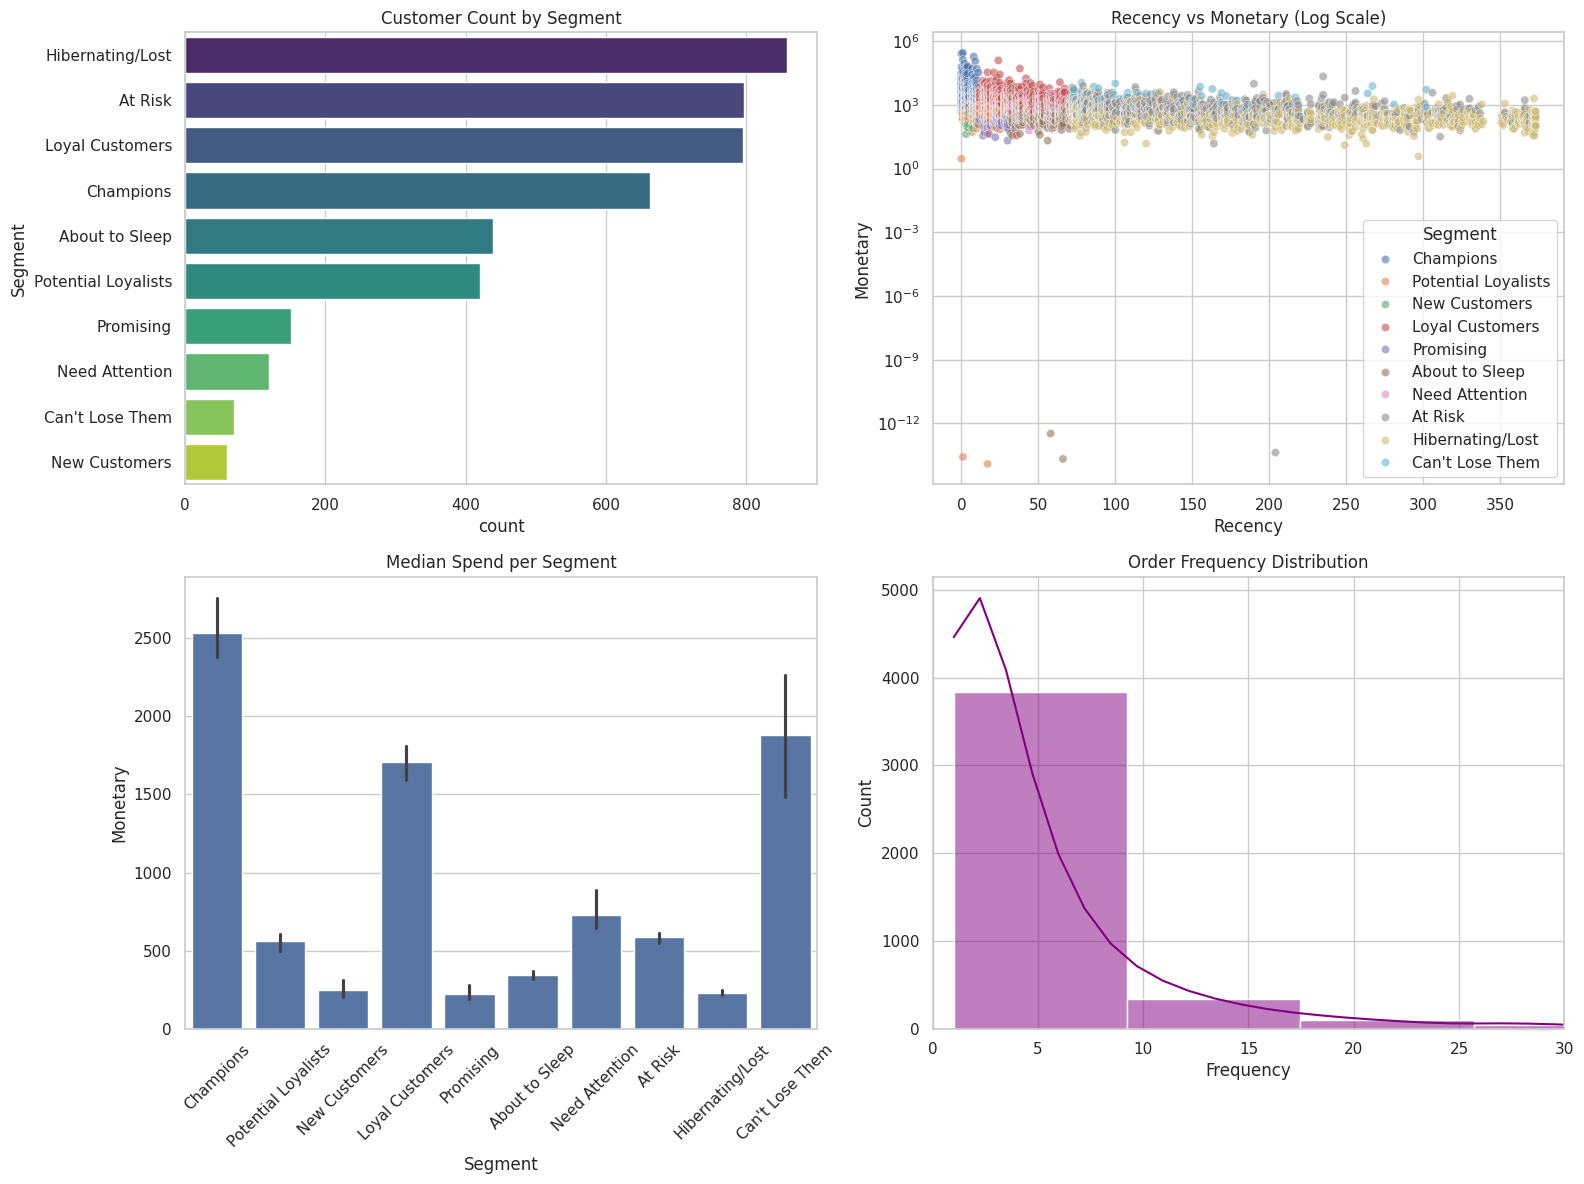

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

# 1. Segment Distribution (Bar Chart)
plt.subplot(2, 2, 1)
sns.countplot(data=df_rfm, y='Segment', palette='viridis', order=df_rfm['Segment'].value_counts().index)
plt.title('Customer Count by Segment')

# 2. Recency vs Monetary (Scatter Plot)
# Helps visualize how "fresh" our big spenders are
plt.subplot(2, 2, 2)
sns.scatterplot(data=df_rfm, x='Recency', y='Monetary', hue='Segment', alpha=0.6)
plt.yscale('log') # Using log scale because 'Whales' skew the data
plt.title('Recency vs Monetary (Log Scale)')

# 3. Median Spend per Segment
plt.subplot(2, 2, 3)
sns.barplot(data=df_rfm, x='Segment', y='Monetary', estimator=lambda x: np.median(x))
plt.xticks(rotation=45)
plt.title('Median Spend per Segment')

# 4. Frequency Distribution
plt.subplot(2, 2, 4)
sns.histplot(df_rfm['Frequency'], bins=30, kde=True, color='purple')
plt.xlim(0, 30) # Zoom in on the majority of customers
plt.title('Order Frequency Distribution')

plt.tight_layout()
plt.show()